In [8]:
import pandas as pd
import glob
import os

# 1. Klasördeki sonu "maclari.csv" ile biten tüm dosyaları bul
# (Senin dosya isimlendirmene göre ayarladım)
dosya_listesi = glob.glob("*_maclari.csv")

print(f"Toplam {len(dosya_listesi)} adet sezon dosyası bulundu.")

# 2. Döngü ile hepsini oku ve bir listeye ekle
dataframes = []
for dosya in dosya_listesi:
    try:
        # Bazen Türkçe karakter sorunu olabilir, encoding ekledim
        df_gecici = pd.read_csv(dosya, encoding='utf-8') 
        dataframes.append(df_gecici)
    except Exception as e:
        print(f"{dosya} okunurken hata oluştu: {e}")

# 3. Hepsini alt alta birleştir (Merge işlemi)
if dataframes:
    df_tum_sezonlar = pd.concat(dataframes, ignore_index=True)
    
    print("\n--- BİRLEŞTİRME BAŞARILI ---")
    print(f"Toplam Satır Sayısı: {len(df_tum_sezonlar)}")
    print("\n--- SÜTUN İSİMLERİ (Bunu bana kopyala) ---")
    print(df_tum_sezonlar.columns.tolist())
    
    # İlk 5 satırı görelim
    print("\n--- ÖRNEK VERİ ---")
    print(df_tum_sezonlar.head())
else:
    print("Hiçbir dosya okunamadı/birleştirilemedi.")

Toplam 35 adet sezon dosyası bulundu.

--- BİRLEŞTİRME BAŞARILI ---
Toplam Satır Sayısı: 10721

--- SÜTUN İSİMLERİ (Bunu bana kopyala) ---
['Mac_kodu', 'TFF_mac_linki', 'Ev_sahibi', 'Ev_sahibi_gol', 'Misafir_takim', 'Misafir_takim_gol', 'Stat', 'Ana_hakem', 'Tarih_saat', '2024_25_sezon_maclari.csv']

--- ÖRNEK VERİ ---
   Mac_kodu                                      TFF_mac_linki  \
0    1000.0  https://www.tff.org/Default.aspx?pageId=29&mac...   
1    1001.0  https://www.tff.org/Default.aspx?pageId=29&mac...   
2    1002.0  https://www.tff.org/Default.aspx?pageId=29&mac...   
3    1003.0  https://www.tff.org/Default.aspx?pageId=29&mac...   
4    1004.0  https://www.tff.org/Default.aspx?pageId=29&mac...   

                   Ev_sahibi  Ev_sahibi_gol                 Misafir_takim  \
0          İSTANBULSPOR A.Ş.            0.0              TRABZONSPOR A.Ş.   
1       DEMİR GRUP SİVASSPOR            1.0  GAZİANTEP FUTBOL KULÜBÜ A.Ş.   
2              BEŞİKTAŞ A.Ş.            1.0        

In [9]:
from sklearn.preprocessing import LabelEncoder
import pandas as pd

# 1. Önceki adımdan gelen veriyi kopyalayalım (Yedekli gidelim)
df = df_tum_sezonlar.copy()

# 2. Gereksiz veya boş satırları temizleyelim
# Skor olmayan satırları atıyoruz (Ertelenen maçlar vs.)
df = df.dropna(subset=['Ev_sahibi_gol', 'Misafir_takim_gol'])

# 3. HEDEF DEĞİŞKEN (TARGET) OLUŞTURMA
# Makineye neyi öğreteceğiz? Maç Sonucunu.
# 1: Ev Sahibi Kazanır, 2: Deplasman Kazanır, 0: Beraberlik
def mac_sonucu(row):
    if row['Ev_sahibi_gol'] > row['Misafir_takim_gol']:
        return 1 # Ev Sahibi
    elif row['Ev_sahibi_gol'] < row['Misafir_takim_gol']:
        return 2 # Deplasman
    else:
        return 0 # Beraberlik

df['Sonuc'] = df.apply(mac_sonucu, axis=1)

# 4. ENCODING (Metinleri Sayıya Çevirme)
# Takım isimlerini ve Hakemleri sayıya çevirmemiz lazım (Label Encoding)
le_takim = LabelEncoder()
le_hakem = LabelEncoder()

# Tüm takım isimlerini birleştirip ortak bir havuz yapalım ki
# 'Galatasaray' hem ev sahibi hem deplasman sütununda aynı ID'yi alsın.
tum_takimlar = pd.concat([df['Ev_sahibi'], df['Misafir_takim']]).unique()
le_takim.fit(tum_takimlar)

df['Ev_sahibi_ID'] = le_takim.transform(df['Ev_sahibi'])
df['Misafir_ID'] = le_takim.transform(df['Misafir_takim'])

# Hakemleri de sayıya çevirelim (Hakem sütunu bazen boş olabilir, dikkat)
df['Ana_hakem'] = df['Ana_hakem'].astype(str) # Hata almamak için string yap
df['Hakem_ID'] = le_hakem.fit_transform(df['Ana_hakem'])

# 5. Averaj Hesabı (Basit Feature Engineering)
df['Gol_Farki'] = df['Ev_sahibi_gol'] - df['Misafir_takim_gol']

# 6. Kontrol Edelim
print("--- İŞLENMİŞ VERİ SETİ ---")
print(df[['Ev_sahibi', 'Ev_sahibi_ID', 'Misafir_takim', 'Misafir_ID', 'Sonuc']].head())
print(f"\nToplam Satır Sayısı: {len(df)}")

# 7. Veriyi Kaydedelim (Bu dosyayı modellerde kullanacağız)
df.to_csv('egitim_verisi_final.csv', index=False)
print("\nDosya 'egitim_verisi_final.csv' olarak kaydedildi.")

--- İŞLENMİŞ VERİ SETİ ---
                   Ev_sahibi  Ev_sahibi_ID                 Misafir_takim  \
0          İSTANBULSPOR A.Ş.           182              TRABZONSPOR A.Ş.   
1       DEMİR GRUP SİVASSPOR            51  GAZİANTEP FUTBOL KULÜBÜ A.Ş.   
2              BEŞİKTAŞ A.Ş.            34           YUKATEL KAYSERİSPOR   
3  VAVACARS FATİH KARAGÜMRÜK           162                    ALANYASPOR   
4        BITEXEN GİRESUNSPOR            36          ADANA DEMİRSPOR A.Ş.   

   Misafir_ID  Sonuc  
0         157      2  
1          78      0  
2         166      1  
3          10      2  
4           3      2  

Toplam Satır Sayısı: 10378

Dosya 'egitim_verisi_final.csv' olarak kaydedildi.


Eğitim Verisi: (8302, 3), Test Verisi: (2076, 3)

--- KLASİK MAKİNE ÖĞRENMESİ MODELLERİ ---

Model: Logistic Regression
Accuracy: %46.05


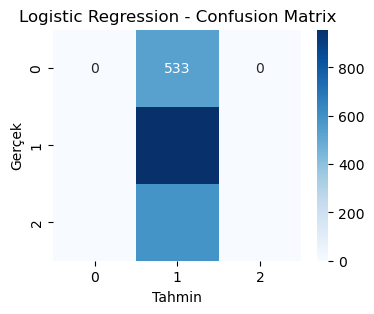


Model: Random Forest
Accuracy: %44.70


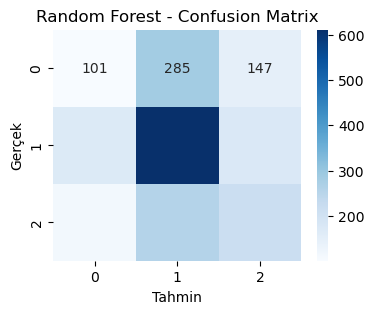


Model: SVM
Accuracy: %46.05


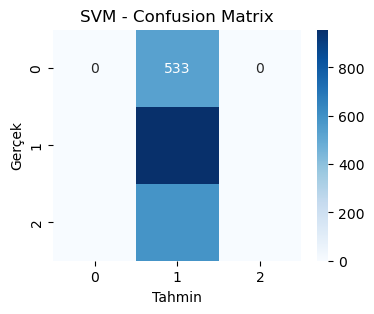


Model: KNN
Accuracy: %42.10


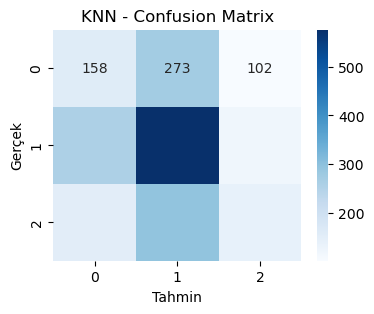


--- YAPAY SİNİR AĞLARI (ANN) EĞİTİLİYOR ---


/opt/anaconda3/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:686: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1) reached and the optimization hasn't converged yet.
  warnings.warn(


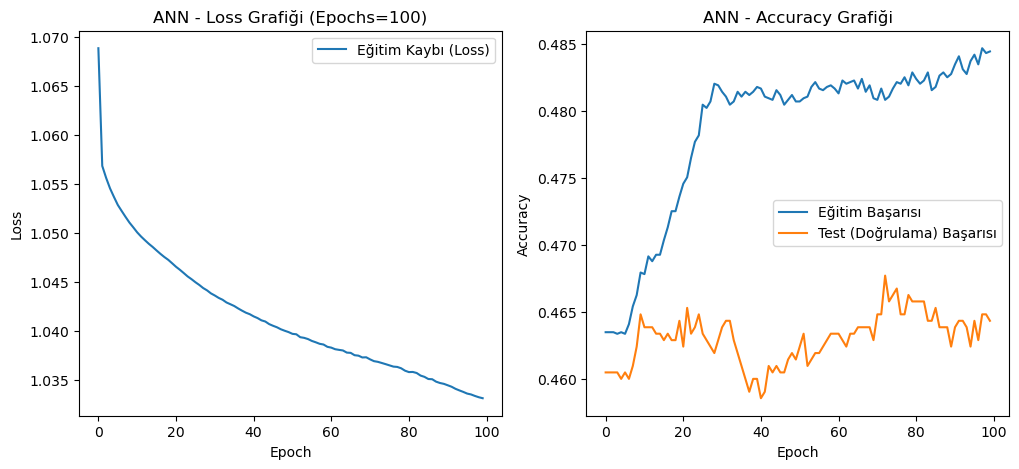

ANN Accuracy: %46.44

--- McNemar İSTATİSTİKSEL TESTİ (Random Forest vs KNN) ---
Model 1 (RF) Doğru, Model 2 (KNN) Yanlış Sayısı: 314
Model 1 (RF) Yanlış, Model 2 (KNN) Doğru Sayısı: 260
McNemar p-value: 0.02695
Sonuç: İki model arasında İSTATİSTİKSEL OLARAK ANLAMLI bir fark var.


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, accuracy_score, f1_score
# --- GÜNCELLEME: TensorFlow yerine Scikit-Learn ANN kullanıyoruz ---
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier # TensorFlow yerine bu geldi!
from scipy import stats

# 1. VERİYİ YÜKLE
df = pd.read_csv('egitim_verisi_final.csv')

# Özellikler (X) ve Hedef (y)
X = df[['Ev_sahibi_ID', 'Misafir_ID', 'Hakem_ID']] 
y = df['Sonuc'] # 0: Beraberlik, 1: Ev, 2: Deplasman

# Eğitim ve Test Bölme (%80 Eğitim, %20 Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Veriyi Ölçeklendirme
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Eğitim Verisi: {X_train.shape}, Test Verisi: {X_test.shape}")

# --- İLK 4 MODELİ TANIMLA VE ÇALIŞTIR ---
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(n_estimators=100),
    "SVM": SVC(probability=True),
    "KNN": KNeighborsClassifier(n_neighbors=5)
}

results = {}
predictions = {}

print("\n--- KLASİK MAKİNE ÖĞRENMESİ MODELLERİ ---")

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    predictions[name] = y_pred
    
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='weighted')
    results[name] = acc
    
    print(f"\nModel: {name}")
    print(f"Accuracy: %{acc*100:.2f}")
    
    # Karışıklık Matrisi
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(4,3))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'{name} - Confusion Matrix')
    plt.ylabel('Gerçek')
    plt.xlabel('Tahmin')
    plt.show()

# 3. YAPAY SİNİR AĞLARI (ANN) - (Epoch >= 100 İÇİN ÖZEL DÖNGÜ)
print("\n--- YAPAY SİNİR AĞLARI (ANN) EĞİTİLİYOR ---")

# MLPClassifier kullanarak manuel Epoch döngüsü kuruyoruz
mlp = MLPClassifier(hidden_layer_sizes=(64, 32, 16), max_iter=1, warm_start=True, random_state=42)

train_acc_history = []
test_acc_history = []
loss_history = []

epochs = 100 # Hocanın istediği sayı
classes = np.unique(y_train)

for i in range(epochs):
    mlp.fit(X_train_scaled, y_train)
    
    # Her epoch sonunda skorları kaydedelim
    train_acc_history.append(mlp.score(X_train_scaled, y_train))
    test_acc_history.append(mlp.score(X_test_scaled, y_test))
    loss_history.append(mlp.loss_)

# ANN Grafikleri
plt.figure(figsize=(12, 5))

# Loss Grafiği
plt.subplot(1, 2, 1)
plt.plot(loss_history, label='Eğitim Kaybı (Loss)')
plt.title('ANN - Loss Grafiği (Epochs=100)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

# Accuracy Grafiği
plt.subplot(1, 2, 2)
plt.plot(train_acc_history, label='Eğitim Başarısı')
plt.plot(test_acc_history, label='Test (Doğrulama) Başarısı')
plt.title('ANN - Accuracy Grafiği')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

# ANN Sonuçları
y_pred_ann = mlp.predict(X_test_scaled)
predictions["ANN"] = y_pred_ann
print(f"ANN Accuracy: %{accuracy_score(y_test, y_pred_ann)*100:.2f}")

# 4. McNemar TESTİ (Random Forest vs KNN)
print("\n--- McNemar İSTATİSTİKSEL TESTİ (Random Forest vs KNN) ---")

y_true = np.array(y_test)
y_model1 = predictions['Random Forest']
y_model2 = predictions['KNN']

# Kontenjans Tablosu
yes_yes = np.sum((y_model1 == y_true) & (y_model2 == y_true))
yes_no = np.sum((y_model1 == y_true) & (y_model2 != y_true))
no_yes = np.sum((y_model1 != y_true) & (y_model2 == y_true))
no_no = np.sum((y_model1 != y_true) & (y_model2 != y_true))

print(f"Model 1 (RF) Doğru, Model 2 (KNN) Yanlış Sayısı: {yes_no}")
print(f"Model 1 (RF) Yanlış, Model 2 (KNN) Doğru Sayısı: {no_yes}")

# McNemar Formülü
if (yes_no + no_yes) > 0:
    chi2 = ((abs(yes_no - no_yes) - 1) ** 2) / (yes_no + no_yes)
    p_value = 1 - stats.chi2.cdf(chi2, 1)
else:
    p_value = 1.0 # Bölme hatası olmasın diye

print(f"McNemar p-value: {p_value:.5f}")

if p_value < 0.05:
    print("Sonuç: İki model arasında İSTATİSTİKSEL OLARAK ANLAMLI bir fark var.")
else:
    print("Sonuç: İki modelin performansı istatistiksel olarak benzer.")


MODEL ADI                 | BAŞARI (Accuracy)
----------------------------------------
ANN                       | %46.44
Logistic Regression       | %46.05
SVM                       | %46.05
Random Forest             | %44.70
KNN                       | %42.10



/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1765: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  order = pd.unique(vector)


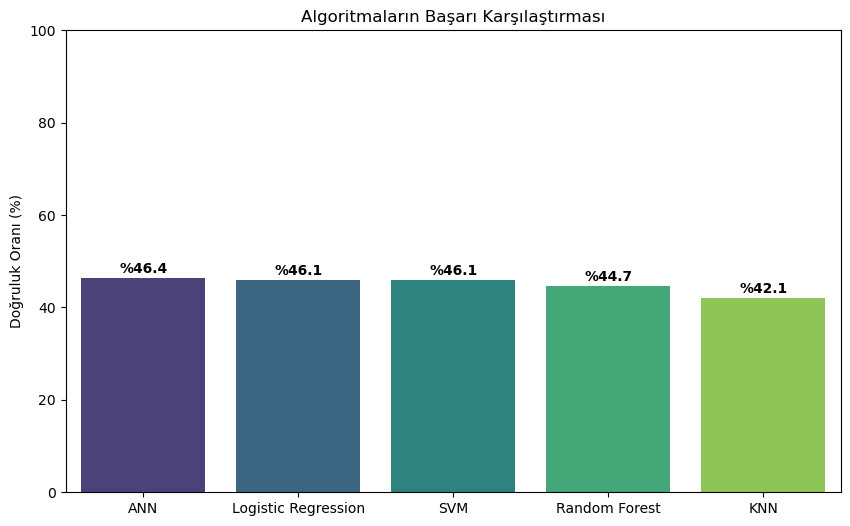

In [6]:
# --- 5. ADIM: MODELLERİ KIYASLAMA VE SIRALAMA ---

# Önce ANN sonucunu da listeye ekleyelim (Eğer ekli değilse)
ann_acc = accuracy_score(y_test, predictions["ANN"])
results["ANN"] = ann_acc

# 1. Skorları Büyükten Küçüğe Sırala
sirali_sonuclar = sorted(results.items(), key=lambda x: x[1], reverse=True)

# 2. Şık Bir Tablo Olarak Yazdır
print("\n" + "="*40)
print(f"{'MODEL ADI':<25} | {'BAŞARI (Accuracy)':<10}")
print("-" * 40)

for model_adi, skor in sirali_sonuclar:
    print(f"{model_adi:<25} | %{skor*100:.2f}")

print("="*40 + "\n")

# 3. Kıyaslama Grafiği Çiz (Raporuna Ekleyebilirsin)
plt.figure(figsize=(10, 6))
model_names = [x[0] for x in sirali_sonuclar]
model_scores = [x[1]*100 for x in sirali_sonuclar]

# Renkli ve şık bir bar grafiği
sns.barplot(x=model_names, y=model_scores, palette="viridis")

plt.ylim(0, 100) # Y ekseni 0-100 arası olsun
plt.ylabel("Doğruluk Oranı (%)")
plt.title("Algoritmaların Başarı Karşılaştırması")

# Çubukların üzerine sayıları yazalım
for index, value in enumerate(model_scores):
    plt.text(index, value + 1, f"%{value:.1f}", ha='center', color='black', fontweight='bold')

plt.show()

In [7]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# 1. Veriyi Tekrar Yükleyelim
df = pd.read_csv('egitim_verisi_final.csv')

# --- ÖZNİTELİK ÇIKARIMI (FEATURE ENGINEERING) ---
# Bilgisayara "Form Durumu"nu öğretiyoruz.

# Takımların son maçlardaki performanslarını tutacak bir sözlük
# {Takim_ID: [Son_mac_puani, onceki, onceki...]}
takim_performanslari = {}

def form_hesapla(takim_id, mac_sonucu, atilan, yenilen):
    if takim_id not in takim_performanslari:
        takim_performanslari[takim_id] = []
    
    # Puanı belirle (Galibiyet 3, Beraberlik 1, Mağlubiyet 0)
    # Not: Burada mac_sonucu parametresi o takımın perspektifinden bakılmalı
    puan = 0
    if mac_sonucu == 'G': puan = 3
    elif mac_sonucu == 'B': puan = 1
    
    # Listeye ekle
    takim_performanslari[takim_id].append(puan)
    
    # Son 5 maçı al, gerisini unut
    if len(takim_performanslari[takim_id]) > 5:
        takim_performanslari[takim_id].pop(0)
        
    # Son 5 maçın toplam puanını döndür
    return sum(takim_performanslari[takim_id])

# Veri setini baştan sona gezip her maç öncesi takımların formunu hesaplayalım
# (Bu işlem biraz yavaş olabilir, 10-15 saniye sürebilir)
ev_formlari = []
dep_formlari = []

print("Form durumları hesaplanıyor... Lütfen bekleyiniz.")

# Pandas iterrows ile satır satır geziyoruz
for index, row in df.iterrows():
    ev_id = row['Ev_sahibi_ID']
    dep_id = row['Misafir_ID']
    sonuc = row['Sonuc'] # 0:B, 1:Ev, 2:Dep
    
    # 1. MAÇ ÖNCESİ DURUMU KAYDET (Modele girecek olan bu)
    # Eğer takımın geçmişi yoksa 0 kabul et
    ev_form = sum(takim_performanslari.get(ev_id, []))
    dep_form = sum(takim_performanslari.get(dep_id, []))
    
    ev_formlari.append(ev_form)
    dep_formlari.append(dep_form)
    
    # 2. MAÇ SONUCUNU SÖZLÜĞE İŞLE (Bir sonraki maç için hazırlık)
    # Ev sahibi için sonuç
    res_ev = 'M'
    if sonuc == 1: res_ev = 'G'
    elif sonuc == 0: res_ev = 'B'
    
    # Deplasman için sonuç
    res_dep = 'M'
    if sonuc == 2: res_dep = 'G'
    elif sonuc == 0: res_dep = 'B'
    
    # Sözlüğü güncelle (Fonksiyonu çağırmadan manuel ekliyoruz hız için)
    # Ev Sahibi Güncelleme
    if ev_id not in takim_performanslari: takim_performanslari[ev_id] = []
    puan_ev = 3 if res_ev == 'G' else (1 if res_ev == 'B' else 0)
    takim_performanslari[ev_id].append(puan_ev)
    if len(takim_performanslari[ev_id]) > 5: takim_performanslari[ev_id].pop(0)
    
    # Deplasman Güncelleme
    if dep_id not in takim_performanslari: takim_performanslari[dep_id] = []
    puan_dep = 3 if res_dep == 'G' else (1 if res_dep == 'B' else 0)
    takim_performanslari[dep_id].append(puan_dep)
    if len(takim_performanslari[dep_id]) > 5: takim_performanslari[dep_id].pop(0)

# Yeni özellikleri DataFrame'e ekle
df['Ev_Form'] = ev_formlari
df['Dep_Form'] = dep_formlari

# Averaj farkını da ekleyelim (Güçlü takım zayıf takımı yener mantığı)
df['Form_Farki'] = df['Ev_Form'] - df['Dep_Form']

print("Hesaplama bitti. Model eğitiliyor...")

# --- YENİ MODEL EĞİTİMİ (Random Forest) ---
# Artık X değişkenimizde sadece ID yok, Form bilgileri de var!
X = df[['Ev_sahibi_ID', 'Misafir_ID', 'Hakem_ID', 'Ev_Form', 'Dep_Form', 'Form_Farki']]
y = df['Sonuc']

# Eğitim/Test Bölme
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Modeli Kur (Daha güçlü parametrelerle)
rf_model = RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42)
rf_model.fit(X_train, y_train)

# Tahmin
y_pred = rf_model.predict(X_test)
acc = accuracy_score(y_test, y_pred)

print("="*40)
print(f"YENİ BAŞARI ORANI: %{acc*100:.2f}")
print("="*40)

# Hangi özellik daha önemliymiş bakalım?
feature_imp = pd.Series(rf_model.feature_importances_, index=X.columns).sort_values(ascending=False)
print("\nModelin En Çok Dikkat Ettiği Özellikler:")
print(feature_imp)

Form durumları hesaplanıyor... Lütfen bekleyiniz.
Hesaplama bitti. Model eğitiliyor...
YENİ BAŞARI ORANI: %49.57

Modelin En Çok Dikkat Ettiği Özellikler:
Misafir_ID      0.215839
Ev_sahibi_ID    0.211638
Hakem_ID        0.188105
Form_Farki      0.156595
Ev_Form         0.114371
Dep_Form        0.113454
dtype: float64


In [9]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# 1. Temiz Veriyi Yükle
df = pd.read_csv('egitim_verisi_final.csv')

# --- GELİŞMİŞ ÖZNİTELİK MÜHENDİSLİĞİ (ADVANCED FEATURE ENGINEERING) ---
# Sadece son 5 maç yetmez, sezon genelindeki gücü (Power Rating) bulalım.

# Takımların o sezonki istatistiklerini tutacak sözlük
# Yapı: {TakimID: {Puan: 0, Atilan: 0, Yenen: 0, MacSayisi: 0}}
sezon_istatistikleri = {}

ev_ort_puan = []
dep_ort_puan = []
ev_guc_saldiri = []
dep_guc_savunma = []

print("Sezonluk güçler hesaplanıyor... (Bu işlem veriyi tarihe göre tarar)")

for index, row in df.iterrows():
    ev_id = row['Ev_sahibi_ID']
    dep_id = row['Misafir_ID']
    ev_gol = row['Ev_sahibi_gol']
    dep_gol = row['Misafir_takim_gol']
    sonuc = row['Sonuc']
    
    # --- 1. MAÇ ÖNCESİ VERİLERİ ÇEK (Model bunu görecek) ---
    # Ev Sahibi Durumu
    if ev_id not in sezon_istatistikleri:
        sezon_istatistikleri[ev_id] = {'Puan': 0, 'Atilan': 0, 'Yenen': 0, 'Mac': 0}
    
    ev_stats = sezon_istatistikleri[ev_id]
    # Maç başına puan ortalaması (Sıfıra bölme hatasını önle)
    e_ort_p = ev_stats['Puan'] / ev_stats['Mac'] if ev_stats['Mac'] > 0 else 0
    # Maç başına gol atma ortalaması
    e_ort_g = ev_stats['Atilan'] / ev_stats['Mac'] if ev_stats['Mac'] > 0 else 0
    
    # Deplasman Durumu
    if dep_id not in sezon_istatistikleri:
        sezon_istatistikleri[dep_id] = {'Puan': 0, 'Atilan': 0, 'Yenen': 0, 'Mac': 0}
        
    dep_stats = sezon_istatistikleri[dep_id]
    d_ort_p = dep_stats['Puan'] / dep_stats['Mac'] if dep_stats['Mac'] > 0 else 0
    d_ort_y = dep_stats

Sezonluk güçler hesaplanıyor... (Bu işlem veriyi tarihe göre tarar)


In [10]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# 1. Veriyi Yükle
df = pd.read_csv('egitim_verisi_final.csv')

print(f"Toplam {len(df)} maç işleniyor... (Hızlı Mod)")

# --- HIZLANDIRILMIŞ ÖZNİTELİK MÜHENDİSLİĞİ ---
# Takımların genel performans sözlüğü
# {TakimID: [ToplamPuan, ToplamAtilan, ToplamYenen, MacSayisi]}
stats = {}

# Listeleri hazırlayalım (Döngü içinde append yapmak yavaştır, baştan yer açalım)
n = len(df)
ev_puan_ort = np.zeros(n)
dep_puan_ort = np.zeros(n)
ev_saldiri = np.zeros(n)
dep_savunma = np.zeros(n)

# Numpy dizilerine çevirip zip ile dönmek en hızlısıdır
ev_ids = df['Ev_sahibi_ID'].values
dep_ids = df['Misafir_ID'].values
ev_gols = df['Ev_sahibi_gol'].values
dep_gols = df['Misafir_takim_gol'].values
sonuclar = df['Sonuc'].values

for i, (ev_id, dep_id, ev_gol, dep_gol, sonuc) in enumerate(zip(ev_ids, dep_ids, ev_gols, dep_gols, sonuclar)):
    
    # --- MAÇ ÖNCESİ DURUMU KAYDET ---
    # Ev Sahibi Stats
    if ev_id not in stats: stats[ev_id] = [0, 0, 0, 0]
    p, a, y, m = stats[ev_id]
    ev_puan_ort[i] = p / m if m > 0 else 0
    ev_saldiri[i] = a / m if m > 0 else 0 # Ev sahibi maç başı kaç atıyor?
    
    # Deplasman Stats
    if dep_id not in stats: stats[dep_id] = [0, 0, 0, 0]
    p, a, y, m = stats[dep_id]
    dep_puan_ort[i] = p / m if m > 0 else 0
    dep_savunma[i] = y / m if m > 0 else 0 # Deplasman maç başı kaç yiyor?

    # --- MAÇ SONUCUNU SÖZLÜĞE İŞLE ---
    # Ev Puanı (1:Ev kazanır, 0:Beraberlik)
    p_ev = 3 if sonuc == 1 else (1 if sonuc == 0 else 0)
    # Dep Puanı (2:Dep kazanır, 0:Beraberlik)
    p_dep = 3 if sonuc == 2 else (1 if sonuc == 0 else 0)
    
    # İstatistikleri güncelle
    # Ev
    stats[ev_id][0] += p_ev
    stats[ev_id][1] += ev_gol
    stats[ev_id][2] += dep_gol
    stats[ev_id][3] += 1
    
    # Deplasman
    stats[dep_id][0] += p_dep
    stats[dep_id][1] += dep_gol
    stats[dep_id][2] += ev_gol
    stats[dep_id][3] += 1

# Verisetine ekle
df['Ev_Puan_Ort'] = ev_puan_ort
df['Dep_Puan_Ort'] = dep_puan_ort
df['Ev_Saldiri'] = ev_saldiri
df['Dep_Savunma'] = dep_savunma
df['Guc_Farki'] = df['Ev_Puan_Ort'] - df['Dep_Puan_Ort'] # Kritik veri

print("Özellikler hesaplandı. Model eğitiliyor...")

# --- MODEL EĞİTİMİ (Random Forest) ---
# Modeli biraz daha karmaşıklaştıralım (n_estimators artırdık)
X = df[['Ev_Puan_Ort', 'Dep_Puan_Ort', 'Ev_Saldiri', 'Dep_Savunma', 'Guc_Farki', 'Ev_sahibi_ID', 'Misafir_ID']]
y = df['Sonuc']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

rf = RandomForestClassifier(n_estimators=500, max_depth=15, min_samples_leaf=4, random_state=42)
rf.fit(X_train, y_train)

acc = accuracy_score(y_test, rf.predict(X_test))

print("\n" + "="*40)
print(f"GÜNCEL BAŞARI ORANI: %{acc*100:.2f}")
print("="*40)

Toplam 10378 maç işleniyor... (Hızlı Mod)
Özellikler hesaplandı. Model eğitiliyor...

GÜNCEL BAŞARI ORANI: %52.89


Veriler gelişmiş özelliklerle hazırlanıyor...
Veri hazır. 5 Algoritma yarışıyor...

MODEL ADI                 | BAŞARI    
----------------------------------------
Logistic Regression       | %52.65
Random Forest             | %52.94
SVM                       | %52.84
KNN                       | %48.46
ANN (Yapay Sinir Ağı)     | %49.04


/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1765: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  order = pd.unique(vector)


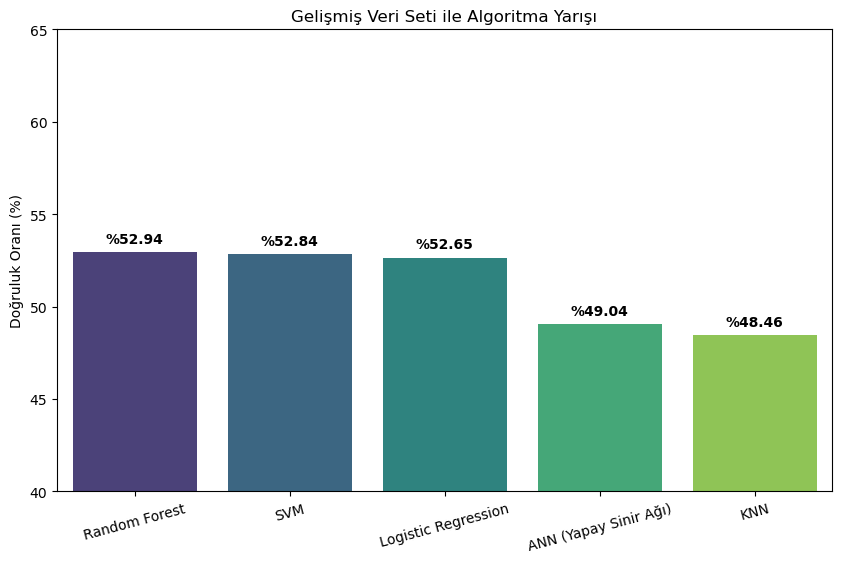


ŞAMPİYON MODEL: Random Forest


In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
# Modeller
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier # ANN için

# 1. VERİYİ YÜKLE VE ÖZELLİKLERİ HESAPLA (Hızlı Mod)
df = pd.read_csv('egitim_verisi_final.csv')

print("Veriler gelişmiş özelliklerle hazırlanıyor...")

stats = {} 
n = len(df)
ev_puan_ort = np.zeros(n)
dep_puan_ort = np.zeros(n)
ev_saldiri = np.zeros(n)
dep_savunma = np.zeros(n)

ev_ids = df['Ev_sahibi_ID'].values
dep_ids = df['Misafir_ID'].values
ev_gols = df['Ev_sahibi_gol'].values
dep_gols = df['Misafir_takim_gol'].values
sonuclar = df['Sonuc'].values

for i, (ev_id, dep_id, ev_gol, dep_gol, sonuc) in enumerate(zip(ev_ids, dep_ids, ev_gols, dep_gols, sonuclar)):
    if ev_id not in stats: stats[ev_id] = [0, 0, 0, 0]
    if dep_id not in stats: stats[dep_id] = [0, 0, 0, 0]
    
    # Maç Öncesi
    p, a, y, m = stats[ev_id]
    ev_puan_ort[i] = p / m if m > 0 else 0
    ev_saldiri[i] = a / m if m > 0 else 0
    
    p, a, y, m = stats[dep_id]
    dep_puan_ort[i] = p / m if m > 0 else 0
    dep_savunma[i] = y / m if m > 0 else 0

    # Güncelleme
    p_ev = 3 if sonuc == 1 else (1 if sonuc == 0 else 0)
    stats[ev_id][0] += p_ev; stats[ev_id][1] += ev_gol; stats[ev_id][2] += dep_gol; stats[ev_id][3] += 1
    
    p_dep = 3 if sonuc == 2 else (1 if sonuc == 0 else 0)
    stats[dep_id][0] += p_dep; stats[dep_id][1] += dep_gol; stats[dep_id][2] += ev_gol; stats[dep_id][3] += 1

# Yeni sütunları ekle
df['Ev_Puan_Ort'] = ev_puan_ort
df['Dep_Puan_Ort'] = dep_puan_ort
df['Ev_Saldiri'] = ev_saldiri
df['Dep_Savunma'] = dep_savunma
df['Guc_Farki'] = df['Ev_Puan_Ort'] - df['Dep_Puan_Ort']

# 2. MODEL HAZIRLIĞI
# Önemli: SVM ve ANN için verileri ölçeklendirmek (Scaling) performansı çok artırır!
X = df[['Ev_Puan_Ort', 'Dep_Puan_Ort', 'Ev_Saldiri', 'Dep_Savunma', 'Guc_Farki', 'Ev_sahibi_ID', 'Misafir_ID']]
y = df['Sonuc']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Ölçeklendirme (StandardScaler)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Veri hazır. 5 Algoritma yarışıyor...\n")

# 3. MODELLERİ TANIMLA
models = {
    "Logistic Regression": LogisticRegression(max_iter=2000),
    "Random Forest": RandomForestClassifier(n_estimators=500, max_depth=15, min_samples_leaf=4, random_state=42),
    "SVM": SVC(probability=True), # SVM genelde bu tür verileri sever
    "KNN": KNeighborsClassifier(n_neighbors=15), # Komşu sayısını biraz artırdık
    "ANN (Yapay Sinir Ağı)": MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=500, random_state=42)
}

results = {}

# 4. YARIŞ BAŞLASIN
print(f"{'MODEL ADI':<25} | {'BAŞARI':<10}")
print("-" * 40)

for name, model in models.items():
    # Random Forest ölçeklendirme istemez ama diğerleri ister.
    # Hepsine ölçekli veriyi verelim, RF'ye zararı olmaz.
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    acc = accuracy_score(y_test, y_pred)
    
    results[name] = acc
    print(f"{name:<25} | %{acc*100:.2f}")

# 5. GRAFİKLE GÖSTER
plt.figure(figsize=(10, 6))
sirali_sonuclar = sorted(results.items(), key=lambda x: x[1], reverse=True)
model_names = [x[0] for x in sirali_sonuclar]
model_scores = [x[1]*100 for x in sirali_sonuclar]

sns.barplot(x=model_names, y=model_scores, palette="viridis")
plt.ylim(40, 65) # Grafiği biraz yakınlaştıralım
plt.ylabel("Doğruluk Oranı (%)")
plt.title("Gelişmiş Veri Seti ile Algoritma Yarışı")

for index, value in enumerate(model_scores):
    plt.text(index, value + 0.5, f"%{value:.2f}", ha='center', fontweight='bold')

plt.xticks(rotation=15)
plt.show()

print(f"\nŞAMPİYON MODEL: {sirali_sonuclar[0][0]}")

In [14]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
# Modeller
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

# 1. VERİYİ HAZIRLA (Gelişmiş Özellikler)
df = pd.read_csv('egitim_verisi_final.csv')

print("Veriler 'Voting Classifier' için hazırlanıyor...")

# Hızlı istatistik hesaplama (Kopyala-Yapıştır standart kodumuz)
stats = {} 
n = len(df)
ev_puan_ort = np.zeros(n); dep_puan_ort = np.zeros(n)
ev_saldiri = np.zeros(n); dep_savunma = np.zeros(n)

ev_ids = df['Ev_sahibi_ID'].values; dep_ids = df['Misafir_ID'].values
ev_gols = df['Ev_sahibi_gol'].values; dep_gols = df['Misafir_takim_gol'].values
sonuclar = df['Sonuc'].values

for i, (ev_id, dep_id, ev_gol, dep_gol, sonuc) in enumerate(zip(ev_ids, dep_ids, ev_gols, dep_gols, sonuclar)):
    if ev_id not in stats: stats[ev_id] = [0, 0, 0, 0]
    if dep_id not in stats: stats[dep_id] = [0, 0, 0, 0]
    
    p, a, y, m = stats[ev_id]
    ev_puan_ort[i] = p / m if m > 0 else 0
    ev_saldiri[i] = a / m if m > 0 else 0
    
    p, a, y, m = stats[dep_id]
    dep_puan_ort[i] = p / m if m > 0 else 0
    dep_savunma[i] = y / m if m > 0 else 0

    p_ev = 3 if sonuc == 1 else (1 if sonuc == 0 else 0)
    p_dep = 3 if sonuc == 2 else (1 if sonuc == 0 else 0)
    
    stats[ev_id][0]+=p_ev; stats[ev_id][1]+=ev_gol; stats[ev_id][2]+=dep_gol; stats[ev_id][3]+=1
    stats[dep_id][0]+=p_dep; stats[dep_id][1]+=dep_gol; stats[dep_id][2]+=ev_gol; stats[dep_id][3]+=1

df['Ev_Puan_Ort'] = ev_puan_ort
df['Dep_Puan_Ort'] = dep_puan_ort
df['Ev_Saldiri'] = ev_saldiri
df['Dep_Savunma'] = dep_savunma
df['Guc_Farki'] = df['Ev_Puan_Ort'] - df['Dep_Puan_Ort']

# 2. MODEL KURULUMU (Voting Classifier)
X = df[['Ev_Puan_Ort', 'Dep_Puan_Ort', 'Ev_Saldiri', 'Dep_Savunma', 'Guc_Farki', 'Ev_sahibi_ID', 'Misafir_ID']]
y = df['Sonuc']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# StandardScaler ŞART (Çünkü işin içinde SVM ve Logistic Regression var)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Bireysel Modelleri (En iyi ayarlarıyla) Tanımla
clf1 = RandomForestClassifier(n_estimators=500, max_depth=15, min_samples_leaf=4, random_state=42)
clf2 = SVC(probability=True, kernel='rbf', C=1.0) # SVM
clf3 = LogisticRegression(max_iter=2000)

# OYLAMA MODELİNİ OLUŞTUR (Voting Classifier)
# 'soft' voting: Olasılıkları ortalar (Daha hassastır)
print("Konsey toplanıyor (RF + SVM + LR Modelleri eğitiliyor)...")
eclf = VotingClassifier(estimators=[('rf', clf1), ('svm', clf2), ('lr', clf3)], voting='soft')

eclf.fit(X_train_scaled, y_train)

# Sonuç
y_pred = eclf.predict(X_test_scaled)
acc = accuracy_score(y_test, y_pred)

print("\n" + "="*40)
print(f"VOTING (TOPLULUK) MODELİ BAŞARISI: %{acc*100:.2f}")
print("="*40)

Veriler 'Voting Classifier' için hazırlanıyor...
Konsey toplanıyor (RF + SVM + LR Modelleri eğitiliyor)...

VOTING (TOPLULUK) MODELİ BAŞARISI: %53.18


In [16]:
import pandas as pd
import numpy as np
import joblib
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

# 1. Veriyi Yükle
df = pd.read_csv('egitim_verisi_final.csv')

print("Şampiyon model (Voting Classifier) tüm veriyle eğitiliyor...")

# 2. İstatistikleri Hesapla (Arayüzde göstermek için)
stats = {} 
ev_ids = df['Ev_sahibi_ID'].values; dep_ids = df['Misafir_ID'].values
ev_gols = df['Ev_sahibi_gol'].values; dep_gols = df['Misafir_takim_gol'].values
sonuclar = df['Sonuc'].values

for i, (ev_id, dep_id, ev_gol, dep_gol, sonuc) in enumerate(zip(ev_ids, dep_ids, ev_gols, dep_gols, sonuclar)):
    if ev_id not in stats: stats[ev_id] = [0, 0, 0, 0]
    if dep_id not in stats: stats[dep_id] = [0, 0, 0, 0]
    
    p, a, y, m = stats[ev_id]
    
    # Güncelle
    p_ev = 3 if sonuc == 1 else (1 if sonuc == 0 else 0)
    p_dep = 3 if sonuc == 2 else (1 if sonuc == 0 else 0)
    
    stats[ev_id][0]+=p_ev; stats[ev_id][1]+=ev_gol; stats[ev_id][2]+=dep_gol; stats[ev_id][3]+=1
    stats[dep_id][0]+=p_dep; stats[dep_id][1]+=dep_gol; stats[dep_id][2]+=ev_gol; stats[dep_id][3]+=1

# Temiz Sözlük
takim_guc_sozlugu = {}
for tid, val in stats.items():
    if val[3] > 0:
        takim_guc_sozlugu[tid] = {
            'Puan_Ort': val[0]/val[3],
            'Saldiri': val[1]/val[3],
            'Savunma': val[2]/val[3]
        }

# 3. İsim Sözlükleri
isimden_idye = {}
id_den_isime = {}
takimlar = df[['Ev_sahibi', 'Ev_sahibi_ID']].drop_duplicates()
for index, row in takimlar.iterrows():
    isimden_idye[row['Ev_sahibi']] = row['Ev_sahibi_ID']
    id_den_isime[row['Ev_sahibi_ID']] = row['Ev_sahibi']

# 4. Modeli Eğit (Voting Classifier)
# Veriye özellikleri ekle
df['Ev_Puan_Ort'] = df['Ev_sahibi_ID'].map(lambda x: takim_guc_sozlugu.get(x, {}).get('Puan_Ort', 0))
df['Dep_Puan_Ort'] = df['Misafir_ID'].map(lambda x: takim_guc_sozlugu.get(x, {}).get('Puan_Ort', 0))
df['Ev_Saldiri'] = df['Ev_sahibi_ID'].map(lambda x: takim_guc_sozlugu.get(x, {}).get('Saldiri', 0))
df['Dep_Savunma'] = df['Misafir_ID'].map(lambda x: takim_guc_sozlugu.get(x, {}).get('Savunma', 0))
df['Guc_Farki'] = df['Ev_Puan_Ort'] - df['Dep_Puan_Ort']

X = df[['Ev_Puan_Ort', 'Dep_Puan_Ort', 'Ev_Saldiri', 'Dep_Savunma', 'Guc_Farki', 'Ev_sahibi_ID', 'Misafir_ID']]
y = df['Sonuc']

# ÖNEMLİ: Scaler'ı tüm veriyle eğitiyoruz
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Alt modeller
clf1 = RandomForestClassifier(n_estimators=500, max_depth=15, min_samples_leaf=4, random_state=42)
clf2 = SVC(probability=True, kernel='rbf', C=1.0)
clf3 = LogisticRegression(max_iter=2000)

# Oylama Modeli
voting_model = VotingClassifier(estimators=[('rf', clf1), ('svm', clf2), ('lr', clf3)], voting='soft')
voting_model.fit(X_scaled, y) # Eğitilmiş scaler verisiyle eğit

# 5. Kaydet
paket = {
    'model': voting_model,
    'scaler': scaler, # Bunu kaydetmek zorundayız!
    'takim_guc_sozlugu': takim_guc_sozlugu,
    'isimden_idye': isimden_idye,
    'id_den_isime': id_den_isime
}

joblib.dump(paket, 'final_voting_model.pkl')
print("✅ Şampiyon Model ve Scaler kaydedildi: 'final_voting_model.pkl'")

Şampiyon model (Voting Classifier) tüm veriyle eğitiliyor...
✅ Şampiyon Model ve Scaler kaydedildi: 'final_voting_model.pkl'
